<div style="display: flex; background-color: #FF6B6B;" >
<h1 style="margin: auto; padding: 30px; color: white; ">Market study for poultry exports</h1>
</div>

<div style="background-color: #4ECDC4;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Step 1 - Importing libraries and loading the file</h2>
</div>

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">1.1 - Importing libraries</h3>
</div>

In [1]:
# Import libraries
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">1.2 - Importing the file</h3>
</div>

In [2]:
df_volaille = pd.read_excel(
    "../data/df_final.xlsx"
)

<div style="background-color: #4ECDC4;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Step 2 - Exploratory analysis of the file</h2>
</div>

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">2.1 - Exploring the file</h3>
</div>

In [3]:
# Dataset dimensions
df_volaille.info()

<class 'pandas.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Name                  181 non-null    str    
 1   ISO 3                 181 non-null    str    
 2   IC                    179 non-null    str    
 3   CC                    181 non-null    float64
 4   PV                    181 non-null    float64
 5   Internet              181 non-null    float64
 6   Chomage               181 non-null    float64
 7   Tourisme              169 non-null    float64
 8   Evolution tourisme    159 non-null    float64
 9   LPI                   155 non-null    float64
 10  Distance capitale     181 non-null    int64  
 11  RL                    181 non-null    float64
 12  RQ                    181 non-null    float64
 13  Population            181 non-null    float64
 14  Evolution population  181 non-null    float64
 15  Production volaille   155 non-null

In [4]:
# PESTEL variables
pestel = [
    "CC",
    "PV",
    "Internet",
    "Chomage",
    "Tourisme",
    "Evolution tourisme",
    "LPI",
    "Distance capitale",
    "RL",
    "RQ",
    "Population",
    "Evolution population",
    "Production volaille",
    "Importation volaille",
    "Dispo alim volaille",
]

In [5]:
# Descriptive statistics of the PESTEL variables
df_volaille[pestel].describe()

,CC,PV,Internet,Chomage,Tourisme,Evolution tourisme,LPI,Distance capitale,RL,RQ,Population,Evolution population,Production volaille,Importation volaille,Dispo alim volaille
count,181.000000,181.000000,181.000000,181.00000,1.690000e+02,159.000000,155.000000,181.000000,181.000000,181.000000,1.810000e+02,181.000000,155.000000,146.000000,165.000000
mean,47.172210,64.909993,52.505766,7.04232,1.240206e+07,74.967355,2.877290,5904.751381,56.074561,55.457348,4.057659e+04,5.591199,780.529032,102.417808,7.003939
std,20.341685,15.198734,28.834513,5.66963,2.885547e+07,125.486823,0.564983,3822.468495,16.510755,14.654536,1.494901e+05,5.277075,2596.743181,198.055365,5.547535
min,14.170000,21.244270,0.000000,0.00000,0.000000e+00,-100.000000,1.950000,0.000000,18.844823,24.750000,3.367100e+01,-12.681196,1.000000,1.000000,0.040000
25%,31.070000,54.492316,25.510401,3.41000,9.230000e+05,17.767580,2.450000,2628.000000,43.497287,44.120000,2.205080e+03,1.967052,19.500000,6.250000,1.970000
50%,43.310000,65.692010,55.799999,5.23800,2.517000e+06,46.524560,2.720000,5513.000000,52.483219,53.190000,8.829628e+03,4.958200,81.000000,23.000000,6.320000
75%,62.060000,78.180968,77.615257,9.31600,8.815000e+06,98.420690,3.225000,8570.000000,67.646093,64.430000,2.912147e+04,9.097374,478.000000,102.750000,9.930000
max,94.470000,91.561385,99.546600,27.03500,2.072740e+08,810.714286,4.200000,19020.000000,92.925652,89.430000,1.421022e+06,23.935417,21914.000000,1069.000000,27.870000


In [6]:
# Check for duplicates in the Name column
print(f"The Name column contains {(df_volaille["Name"].duplicated().sum())} duplicates")

The Name column contains 0 duplicates


Some variables have missing values, no country is duplicated, and some values need investigating (zeros in unemployment and internet access).

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">2.2 - Investigating missing values</h3>
</div>

In [7]:
# Count missing values per country
df_volaille["nb_nan"] = df_volaille[pestel].isnull().sum(axis=1)
print("Distribution of missing values per country")
print(df_volaille["nb_nan"].value_counts().sort_index())

Distribution of missing values per country
nb_nan
0    105
1     43
2     17
3      7
4      7
5      1
6      1
Name: count, dtype: int64


In [8]:
# Countries with 3 or more missing values
print(
    df_volaille[df_volaille["nb_nan"] >= 3][["Name", "nb_nan"]].to_string(index=False)
)

                 Name  nb_nan
              Bahrain       3
               Bhutan       3
    Brunei Darussalam       4
              Burundi       3
              Comoros       4
    Equatorial Guinea       3
              Eritrea       4
        Liechtenstein       5
     Marshall Islands       4
Micronesia, Fed. Sts.       6
     Papua New Guinea       3
                Qatar       4
           San Marino       4
           Seychelles       4
            Singapore       3
 Syrian Arab Republic       3


With 15 variables, we set a threshold of about 13%, i.e. a strict maximum of 2 missing values per country. Beyond that, the country's profile would be too incomplete.

In [9]:
# Remove countries with more than 2 missing values
df_volaille = df_volaille[df_volaille["nb_nan"] <= 2]

In [10]:
# Drop the nb_nan column
df_volaille = df_volaille.drop(columns=["nb_nan"])

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">2.3 - Internet access and unemployment</h3>
</div>

In [11]:
# Countries with 0 unemployment or 0 internet access
df_internet_chomage_0 = df_volaille[
    (df_volaille["Internet"] == 0) | (df_volaille["Chomage"] == 0)
]
df_internet_chomage_0

,Name,ISO 3,IC,CC,PV,Internet,Chomage,Tourisme,Evolution tourisme,LPI,Distance capitale,RL,RQ,Population,Evolution population,Production volaille,Importation volaille,Dispo alim volaille
45,Dominica,DMA,Upper middle income,60.43,84.844524,69.619698,0.000,230000.000,-50.854701,NaN,6944,68.996080,57.61,71.458,0.622395,NaN,4.0,11.52
64,Grenada,GRD,Upper middle income,56.98,81.497972,54.200001,0.000,468000.000,9.345794,NaN,7083,66.587149,54.10,110.874,2.499769,1.0,7.0,15.50
137,Samoa,WSM,Upper middle income,60.32,84.155398,0.000000,9.400,158000.000,29.508197,NaN,16059,73.772394,56.15,195.352,2.429765,NaN,17.0,21.88
152,St. Kitts and Nevis,KNA,High income,57.29,77.189475,67.784401,0.000,1194000.000,124.015009,NaN,6738,71.633086,62.56,52.045,3.400000,NaN,4.0,19.22
168,Turkmenistan,TKM,Upper middle income,18.45,61.984095,0.000000,4.035,0.000,NaN,2.41,4632,31.487999,26.66,5757.667,7.291492,20.0,9.0,1.53
176,Vanuatu,VUT,Lower middle income,46.51,80.456464,0.000000,5.247,332700.012,NaN,NaN,16172,65.093351,49.42,285.510,11.251388,1.0,4.0,4.05
177,"Venezuela, RB",VEN,NaN,18.45,42.320681,0.000000,5.045,429000.000,-38.888889,2.23,7643,18.844823,25.99,29402.484,-1.270000,600.0,25.0,7.23


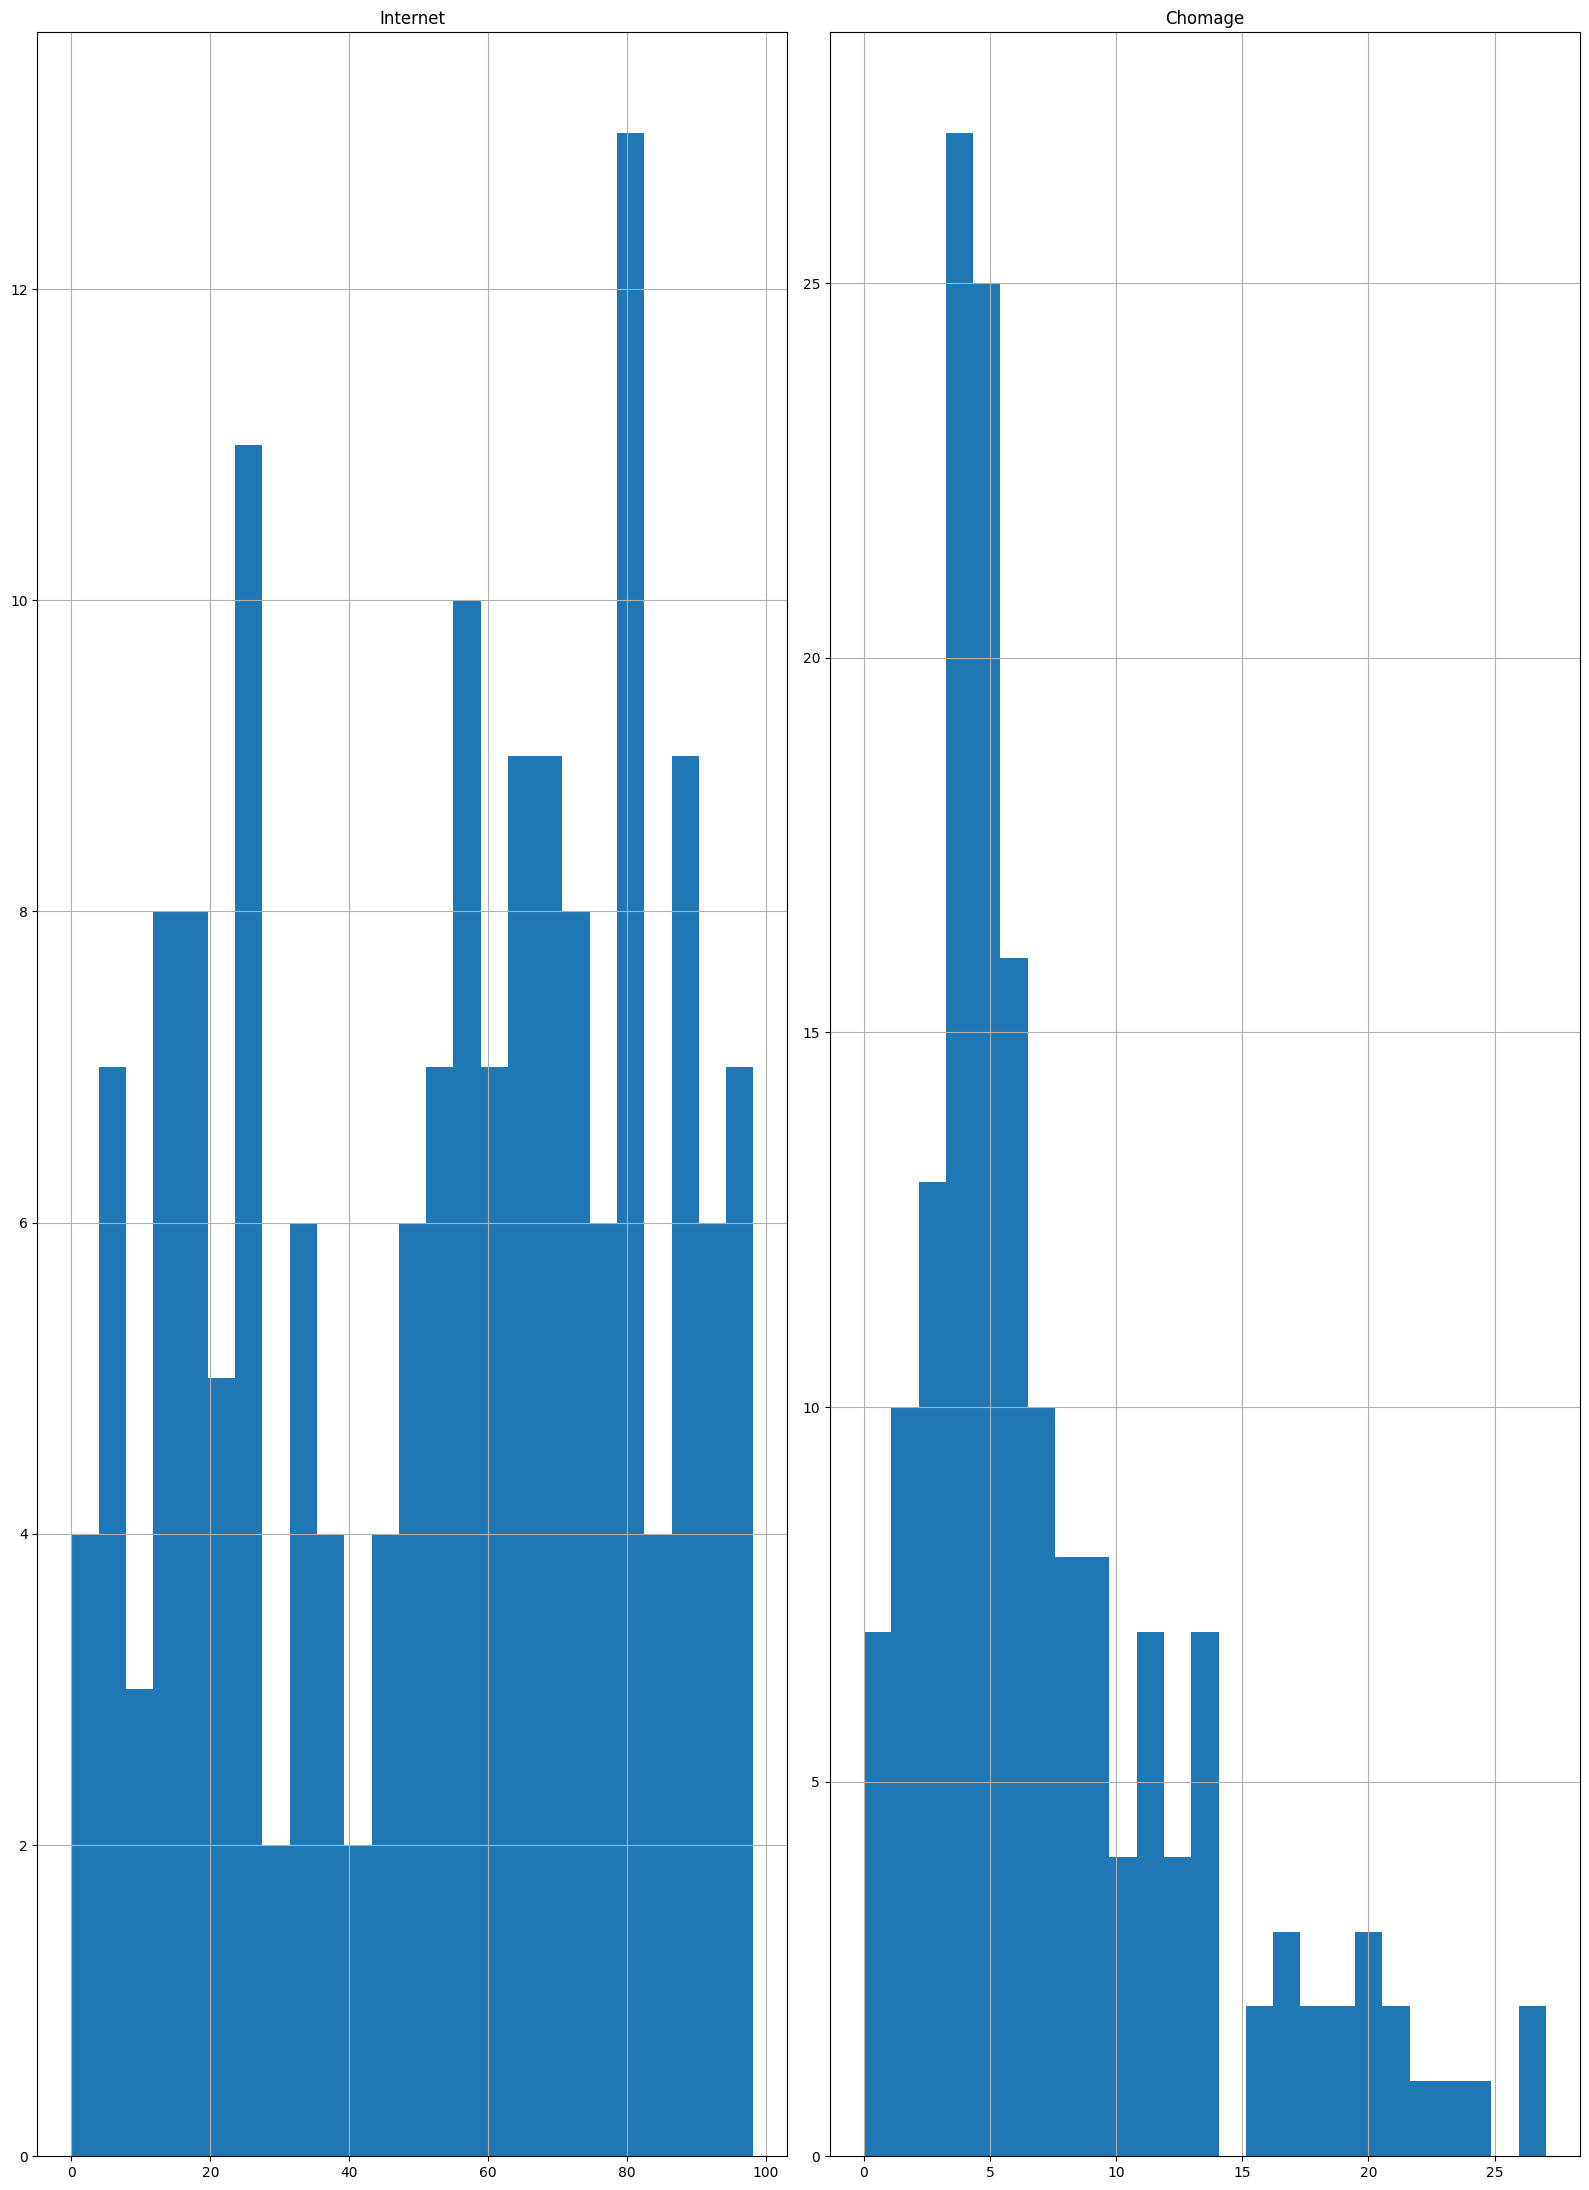

In [12]:
# Plot the distribution of the variables
df_volaille[["Internet", "Chomage"]].hist(bins=25, figsize=(16, 22))
plt.tight_layout()
plt.show()

Unemployment has a strongly skewed distribution, while internet access is bimodal with two distinct concentrations. We will therefore impute both variables with the median.

In [13]:
# Assign Venezuela's last known income classification
df_volaille.loc[df_volaille["Name"] == "Venezuela, RB", "IC"] = "Upper middle income"

In [14]:
# Turn zeros into missing values
df_volaille.loc[df_volaille["Internet"] == 0, "Internet"] = np.nan
df_volaille.loc[df_volaille["Chomage"] == 0, "Chomage"] = np.nan

In [15]:
# Impute with the median of each income group (World Bank income classification)
for col in ["Internet", "Chomage"]:
    df_volaille[col] = df_volaille.groupby("IC")[col].transform(
        lambda x: x.fillna(x.median())
    )

In [16]:
# Check the imputation
df_volaille[pestel].describe()

,CC,PV,Internet,Chomage,Tourisme,Evolution tourisme,LPI,Distance capitale,RL,RQ,Population,Evolution population,Production volaille,Importation volaille,Dispo alim volaille
count,165.000000,165.000000,164.000000,164.000000,1.560000e+02,149.000000,144.000000,165.000000,165.000000,165.000000,1.650000e+02,165.000000,154.000000,145.000000,165.000000
mean,46.733212,64.563339,54.159778,7.557274,1.318025e+07,73.652885,2.897222,5764.739394,56.045060,55.746242,4.418836e+04,5.520150,785.493506,103.096552,7.003939
std,19.688193,14.424508,26.936420,5.599068,2.987227e+07,112.513330,0.557373,3753.790505,16.213759,14.246516,1.561308e+05,5.079123,2604.477382,198.571402,5.547535
min,14.170000,21.244270,4.000000,0.141000,0.000000e+00,-100.000000,1.950000,0.000000,18.844823,25.990000,5.204500e+01,-5.434483,1.000000,1.000000,0.040000
25%,31.640000,54.734172,27.200001,3.771750,1.022500e+06,19.270239,2.505000,2285.000000,43.633055,44.500000,2.944791e+03,1.828215,20.000000,7.000000,1.970000
50%,42.550000,65.410950,58.025813,5.592000,3.061000e+06,46.524560,2.750000,5503.000000,51.872463,53.750000,9.785843e+03,4.899617,83.000000,23.000000,6.320000
75%,59.880000,77.222615,76.966724,9.575000,1.048500e+07,98.630137,3.240000,8533.000000,67.620156,64.430000,3.144430e+04,9.095768,485.500000,104.000000,9.930000
max,94.470000,91.388422,98.255201,27.035000,2.072740e+08,778.048780,4.200000,19020.000000,92.925652,89.430000,1.421022e+06,23.935417,21914.000000,1069.000000,27.870000


In [17]:
# Investigate the last missing value
df_volaille[df_volaille["Internet"].isna() | df_volaille["Chomage"].isna()][
    ["Name", "ISO 3 ", "IC", "Internet", "Chomage"]
]

,Name,ISO 3,IC,Internet,Chomage
54,Ethiopia,ETH,NaN,NaN,NaN


In [18]:
# Ethiopia's row
df_volaille[df_volaille["Name"] == "Ethiopia"]

,Name,ISO 3,IC,CC,PV,Internet,Chomage,Tourisme,Evolution tourisme,LPI,Distance capitale,RL,RQ,Population,Evolution population,Production volaille,Importation volaille,Dispo alim volaille
54,Ethiopia,ETH,NaN,36.42,39.937663,NaN,NaN,933000.0,143.603133,NaN,5513,43.497287,40.69,106399.924,11.546924,14.0,1.0,0.04


Ethiopia has 3 missing values and is therefore removed from the study.

In [19]:
# Remove the country
df_volaille = df_volaille[df_volaille["Name"] != "Ethiopia"].copy()

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">2.4 - Tourism and tourism growth</h3>
</div>

In [20]:
# Inspect missing values
df_volaille[df_volaille["Tourisme"].isna() | df_volaille["Evolution tourisme"].isna()][
    ["Name", "IC", "Tourisme", "Evolution tourisme"]
]

,Name,IC,Tourisme,Evolution tourisme
0,Afghanistan,Low income,NaN,NaN
30,Central African Republic,Low income,1.070000e+05,NaN
36,"Congo, Rep.",Lower middle income,1.510000e+05,NaN
44,Djibouti,Lower middle income,NaN,-100.0
58,Gabon,Upper middle income,NaN,NaN
62,Ghana,Lower middle income,NaN,-100.0
63,Greece,High income,3.016100e+07,NaN
77,Iraq,Upper middle income,NaN,-100.0
93,Liberia,Low income,NaN,NaN
98,Madagascar,Low income,2.850000e+05,NaN


In [21]:
# Impute missing values with 0
df_volaille["Tourisme"] = df_volaille["Tourisme"].fillna(0)
df_volaille["Evolution tourisme"] = df_volaille["Evolution tourisme"].fillna(0)

Missing values for these variables are mostly due to the absence of official tourism statistics (political instability, very small states). We imputed them with 0, considering that the absence of data reflects a negligible tourism activity.

In [22]:
# Countries with a tourism growth of -100
df_volaille[df_volaille["Evolution tourisme"] == -100][
    ["Name", "ISO 3 ", "IC", "Tourisme", "Evolution tourisme"]
]

,Name,ISO 3,IC,Tourisme,Evolution tourisme
44,Djibouti,DJI,Lower middle income,0.0,-100.0
62,Ghana,GHA,Lower middle income,0.0,-100.0
77,Iraq,IRQ,Upper middle income,0.0,-100.0
121,Nigeria,NGA,Lower middle income,0.0,-100.0
125,Pakistan,PAK,Lower middle income,0.0,-100.0


In [23]:
# Set the -100 values to 0
df_volaille.loc[df_volaille["Evolution tourisme"] == -100, "Evolution tourisme"] = 0

Tourism growth is calculated relative to the initial tourism figure, which explains why some countries show -100 (division impossible). They were also set to 0, since the two variables are linked.

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">2.5 - Logistics Performance Index (LPI)</h3>
</div>

In [24]:
# Inspect missing values
df_volaille[df_volaille["LPI"].isna()][["Name", "IC", "LPI"]]

,Name,IC,LPI
8,Azerbaijan,Upper middle income,NaN
12,Barbados,High income,NaN
15,Belize,Upper middle income,NaN
20,Botswana,Upper middle income,NaN
26,Cabo Verde,Upper middle income,NaN
45,Dominica,Upper middle income,NaN
53,Eswatini,Lower middle income,NaN
64,Grenada,Upper middle income,NaN
97,"Macao SAR, China",High income,NaN
113,Mozambique,Low income,NaN


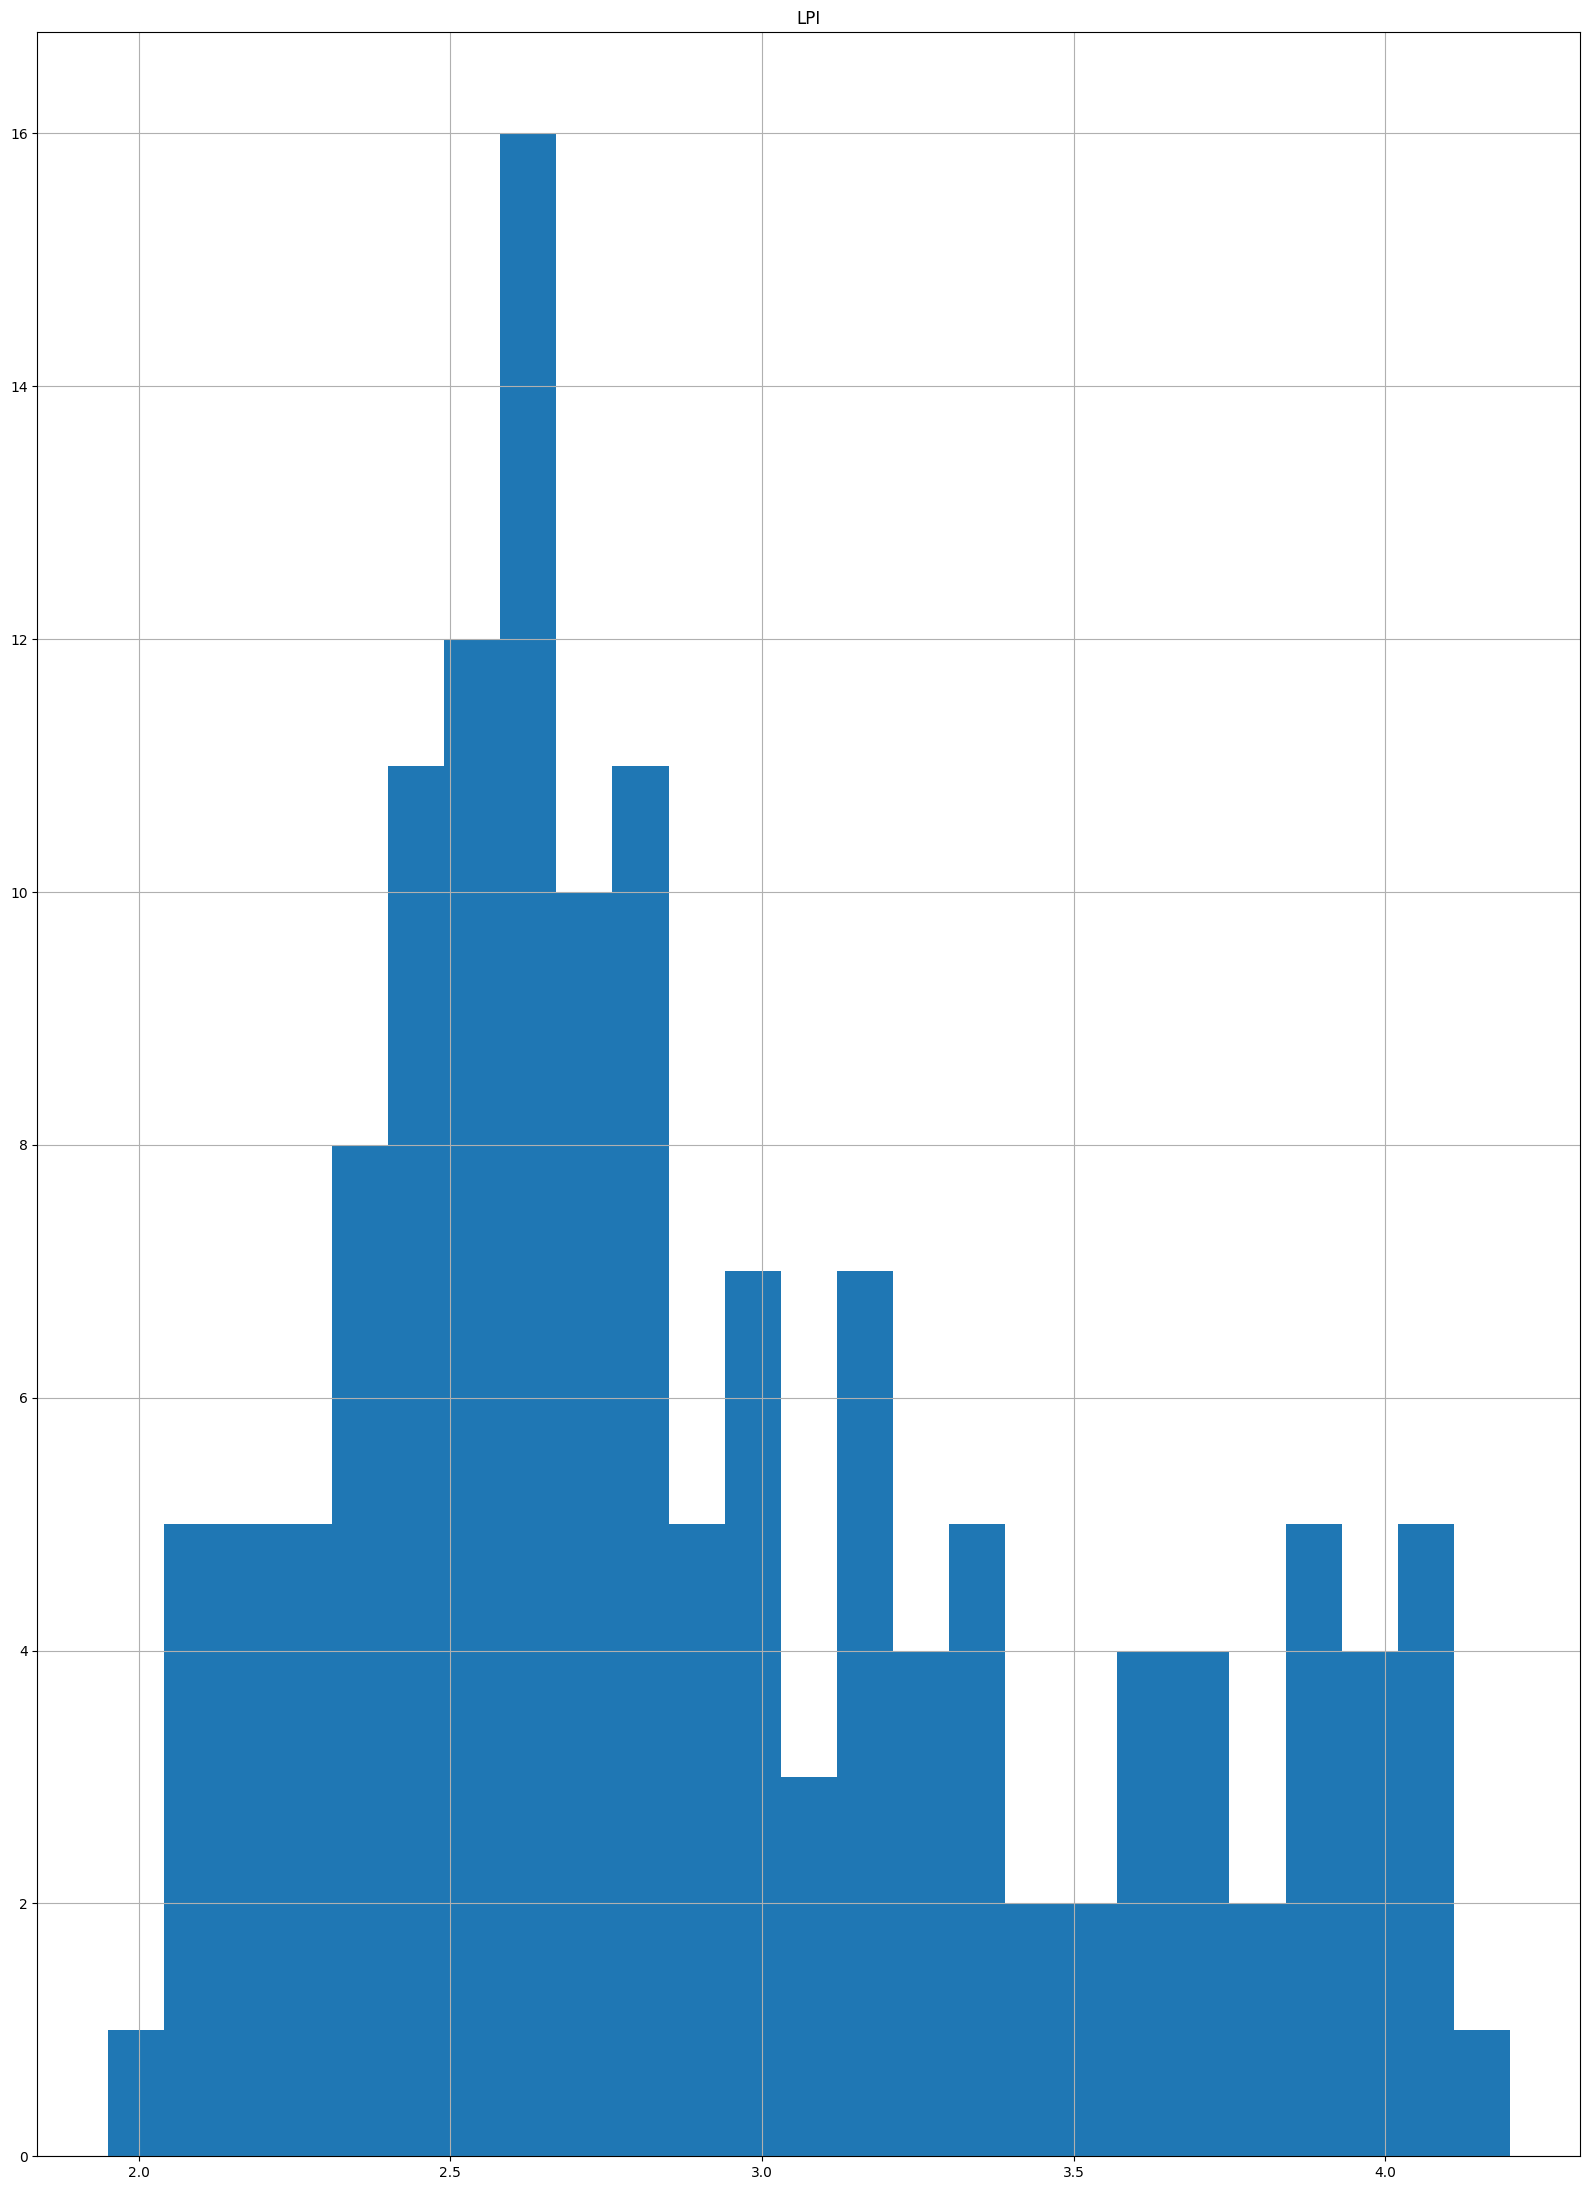

In [25]:
# Plot the distribution of the variable
df_volaille[["LPI"]].hist(bins=25, figsize=(16, 22))
plt.tight_layout()
plt.show()

The LPI is slightly right-skewed, so we will impute it with the median.

In [26]:
# Impute with the median
for col in ["LPI"]:
    df_volaille[col] = df_volaille.groupby("IC")[col].transform(
        lambda x: x.fillna(x.median())
    )

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">2.6 - Poultry imports and production</h3>
</div>

In [27]:
# Inspect missing values
df_volaille[
    df_volaille["Production volaille"].isna()
    | df_volaille["Importation volaille"].isna()
][["Name", "IC", "Production volaille", "Importation volaille"]]

,Name,IC,Production volaille,Importation volaille
11,Bangladesh,Lower middle income,249.0,NaN
15,Belize,Upper middle income,20.0,NaN
24,Burkina Faso,Low income,46.0,NaN
28,Cameroon,Lower middle income,81.0,NaN
44,Djibouti,Lower middle income,NaN,3.0
45,Dominica,Upper middle income,NaN,4.0
47,Ecuador,Upper middle income,340.0,NaN
68,Guyana,High income,31.0,NaN
74,India,Lower middle income,3545.0,NaN
79,Israel,High income,629.0,NaN


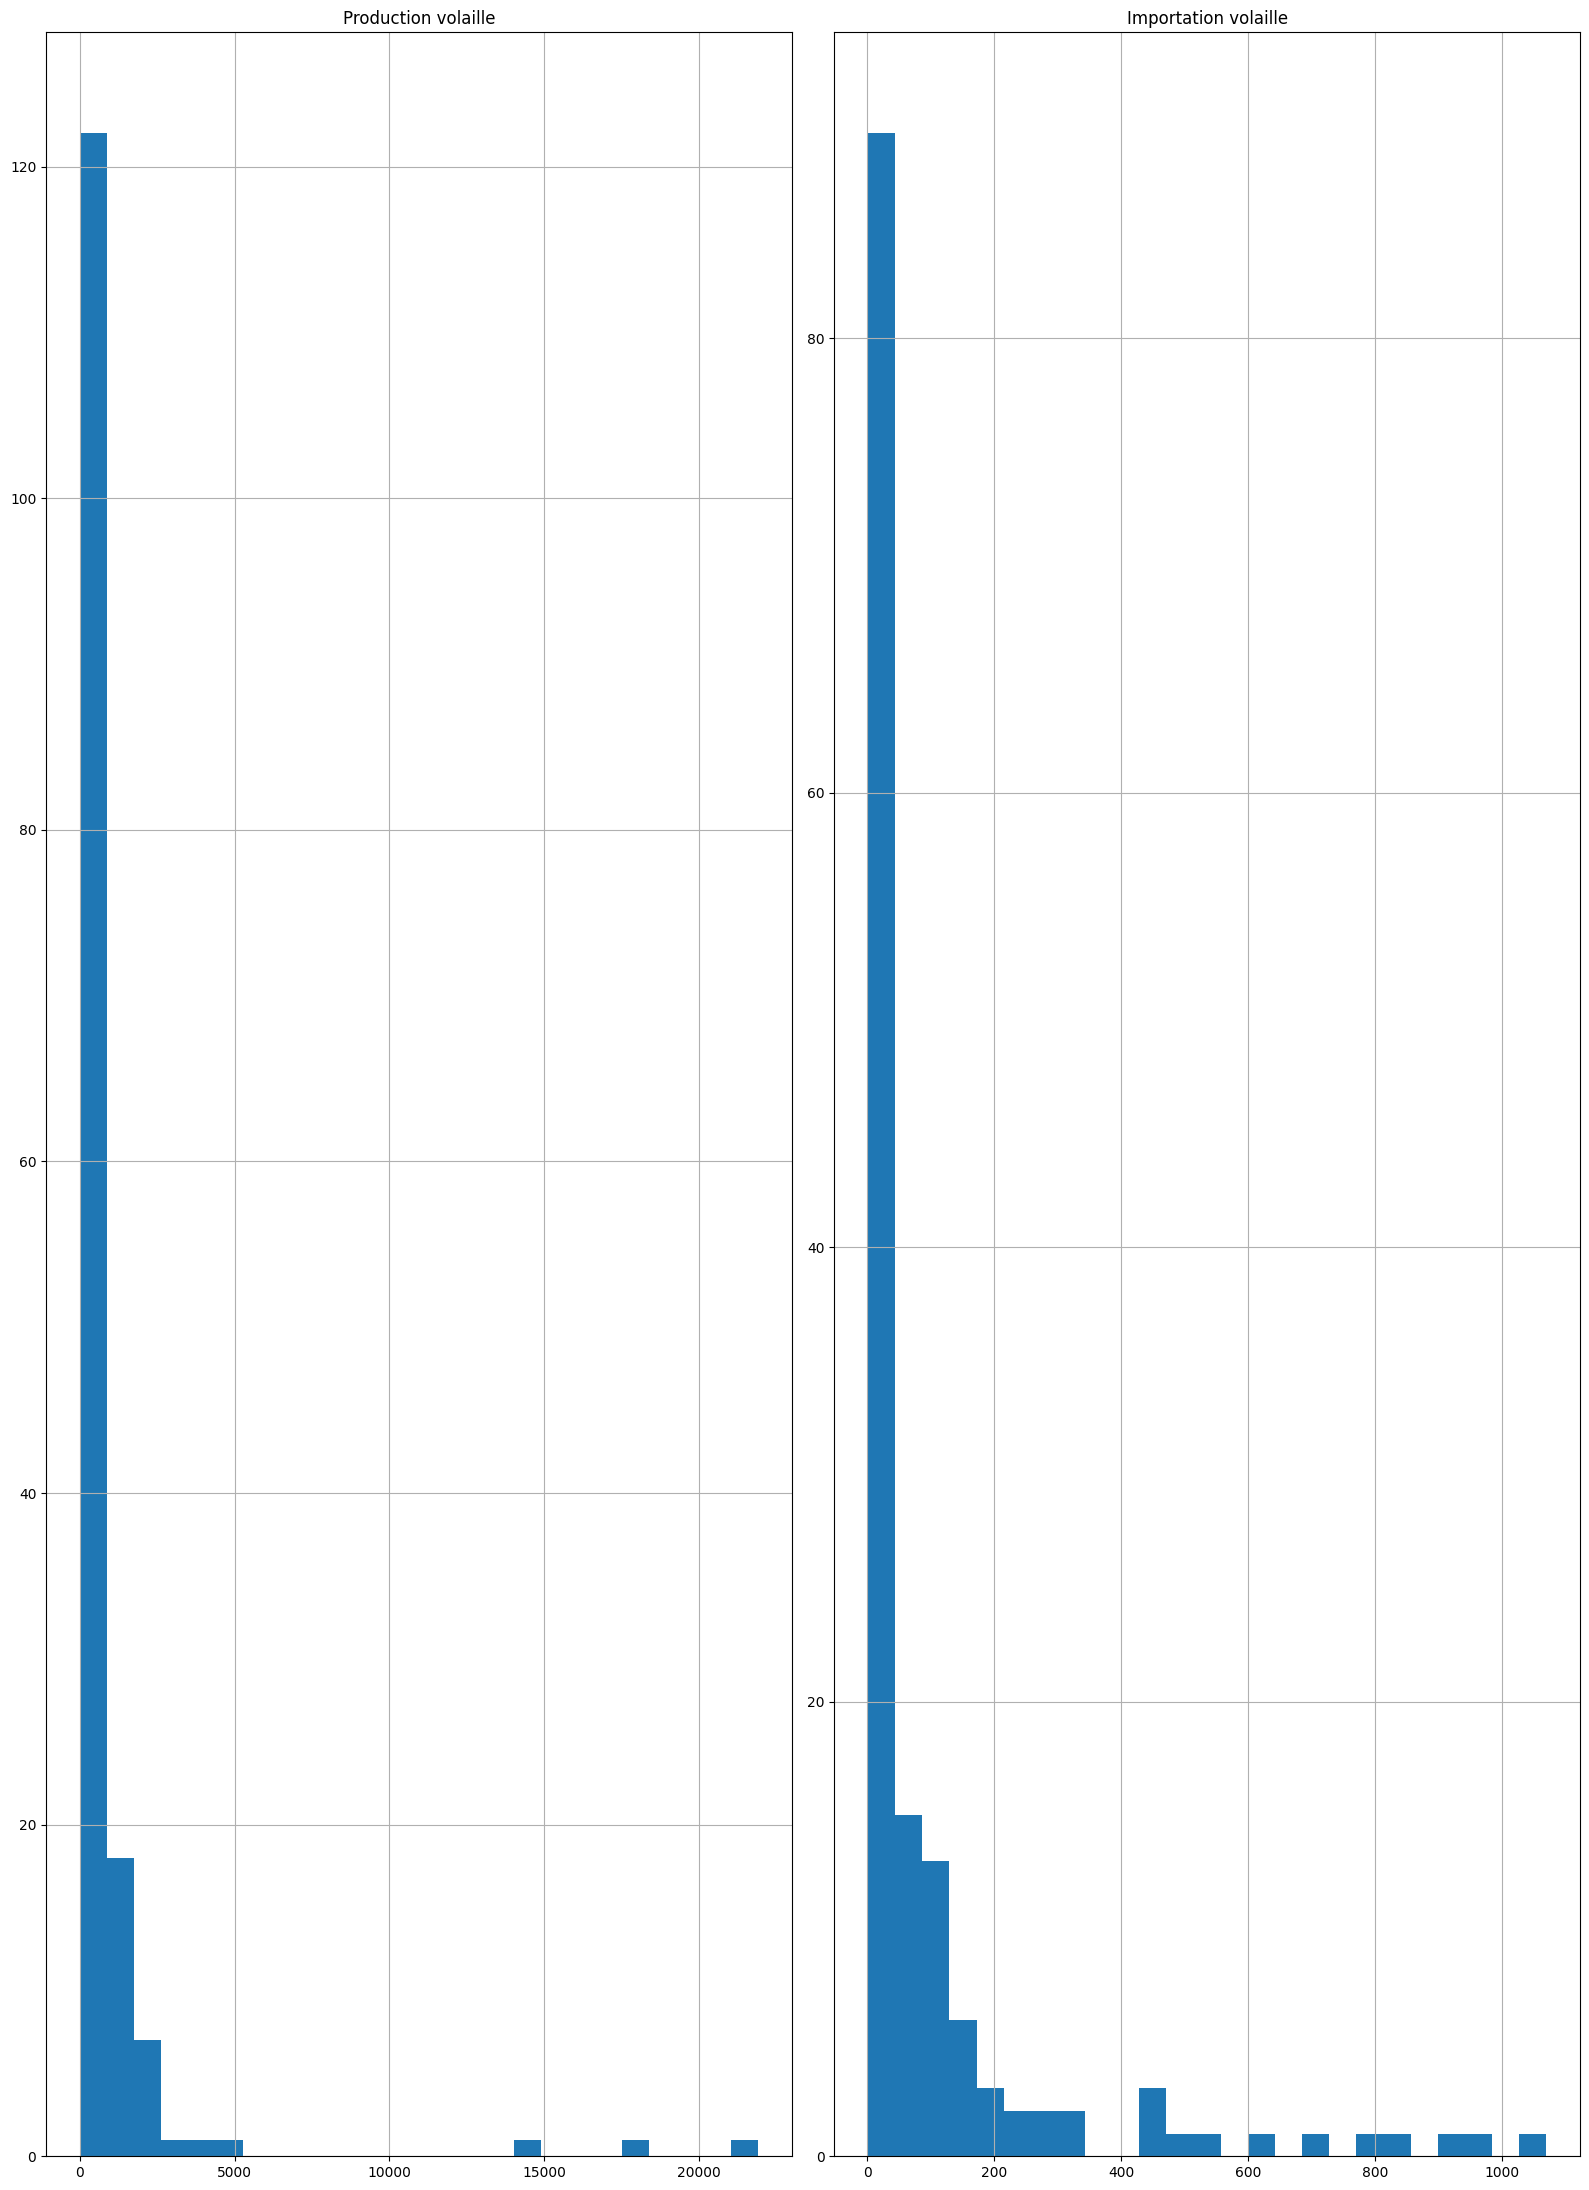

In [28]:
# Plot the distribution of the variables
df_volaille[["Production volaille", "Importation volaille"]].hist(
    bins=25, figsize=(16, 22)
)
plt.tight_layout()
plt.show()

Both variables are strongly right-skewed. The median will therefore be used for imputation.

In [29]:
# Impute with the median
for col in ["Production volaille", "Importation volaille"]:
    df_volaille[col] = df_volaille.groupby("IC")[col].transform(
        lambda x: x.fillna(x.median())
    )

In [30]:
# Final check
df_volaille.describe()

,CC,PV,Internet,Chomage,Tourisme,Evolution tourisme,LPI,Distance capitale,RL,RQ,Population,Evolution population,Production volaille,Importation volaille,Dispo alim volaille
count,164.000000,164.000000,164.000000,164.000000,1.640000e+02,164.000000,164.000000,164.00000,164.000000,164.000000,1.640000e+02,164.000000,164.000000,164.000000,164.000000
mean,46.796098,64.713496,54.159778,7.557274,1.253162e+07,69.089492,2.881463,5766.27439,56.121571,55.838049,4.380902e+04,5.483402,744.420732,93.402439,7.046402
std,19.731865,14.338753,26.936420,5.599068,2.927122e+07,105.911287,0.535716,3765.23565,16.233513,14.241108,1.565328e+05,5.072629,2528.499698,188.697813,5.537564
min,14.170000,21.244270,4.000000,0.141000,0.000000e+00,-70.107108,1.950000,0.00000,18.844823,25.990000,5.204500e+01,-5.434483,1.000000,1.000000,0.150000
25%,31.572500,55.390281,27.200001,3.771750,6.587500e+05,8.779110,2.530000,2227.00000,43.822409,44.702500,2.938805e+03,1.788537,22.750000,9.000000,2.165000
50%,42.580000,65.551480,58.025813,5.592000,2.484000e+06,40.576189,2.700000,5443.50000,52.002050,53.805000,9.757833e+03,4.763012,91.500000,17.000000,6.405000
75%,59.990000,77.267999,76.966724,9.575000,8.492500e+06,93.442002,3.205000,8542.25000,67.677028,64.545000,3.118956e+04,9.091442,409.750000,82.500000,9.972500
max,94.470000,91.388422,98.255201,27.035000,2.072740e+08,778.048780,4.200000,19020.00000,92.925652,89.430000,1.421022e+06,23.935417,21914.000000,1069.000000,27.870000


World population data come from the FAO and were converted directly into thousands to make the world coverage calculation easier.

In [31]:
# Final check
population_mondiale_2017 = 7540000
print(f"Remaining missing values: {df_volaille[pestel].isnull().sum().sum()}")
print(f"Countries: {len(df_volaille)}")
print(
    f"World population coverage: {df_volaille['Population'].sum()/ population_mondiale_2017 * 100:.2f} %"
)

Remaining missing values: 0
Countries: 164
World population coverage: 95.29 %


Our final dataset contains 164 countries covering 95.29% of the world population, well above the 60% threshold required by the brief. No values are missing anymore. We can move on to the study of outliers.

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">2.7 - Outliers</h3>
</div>

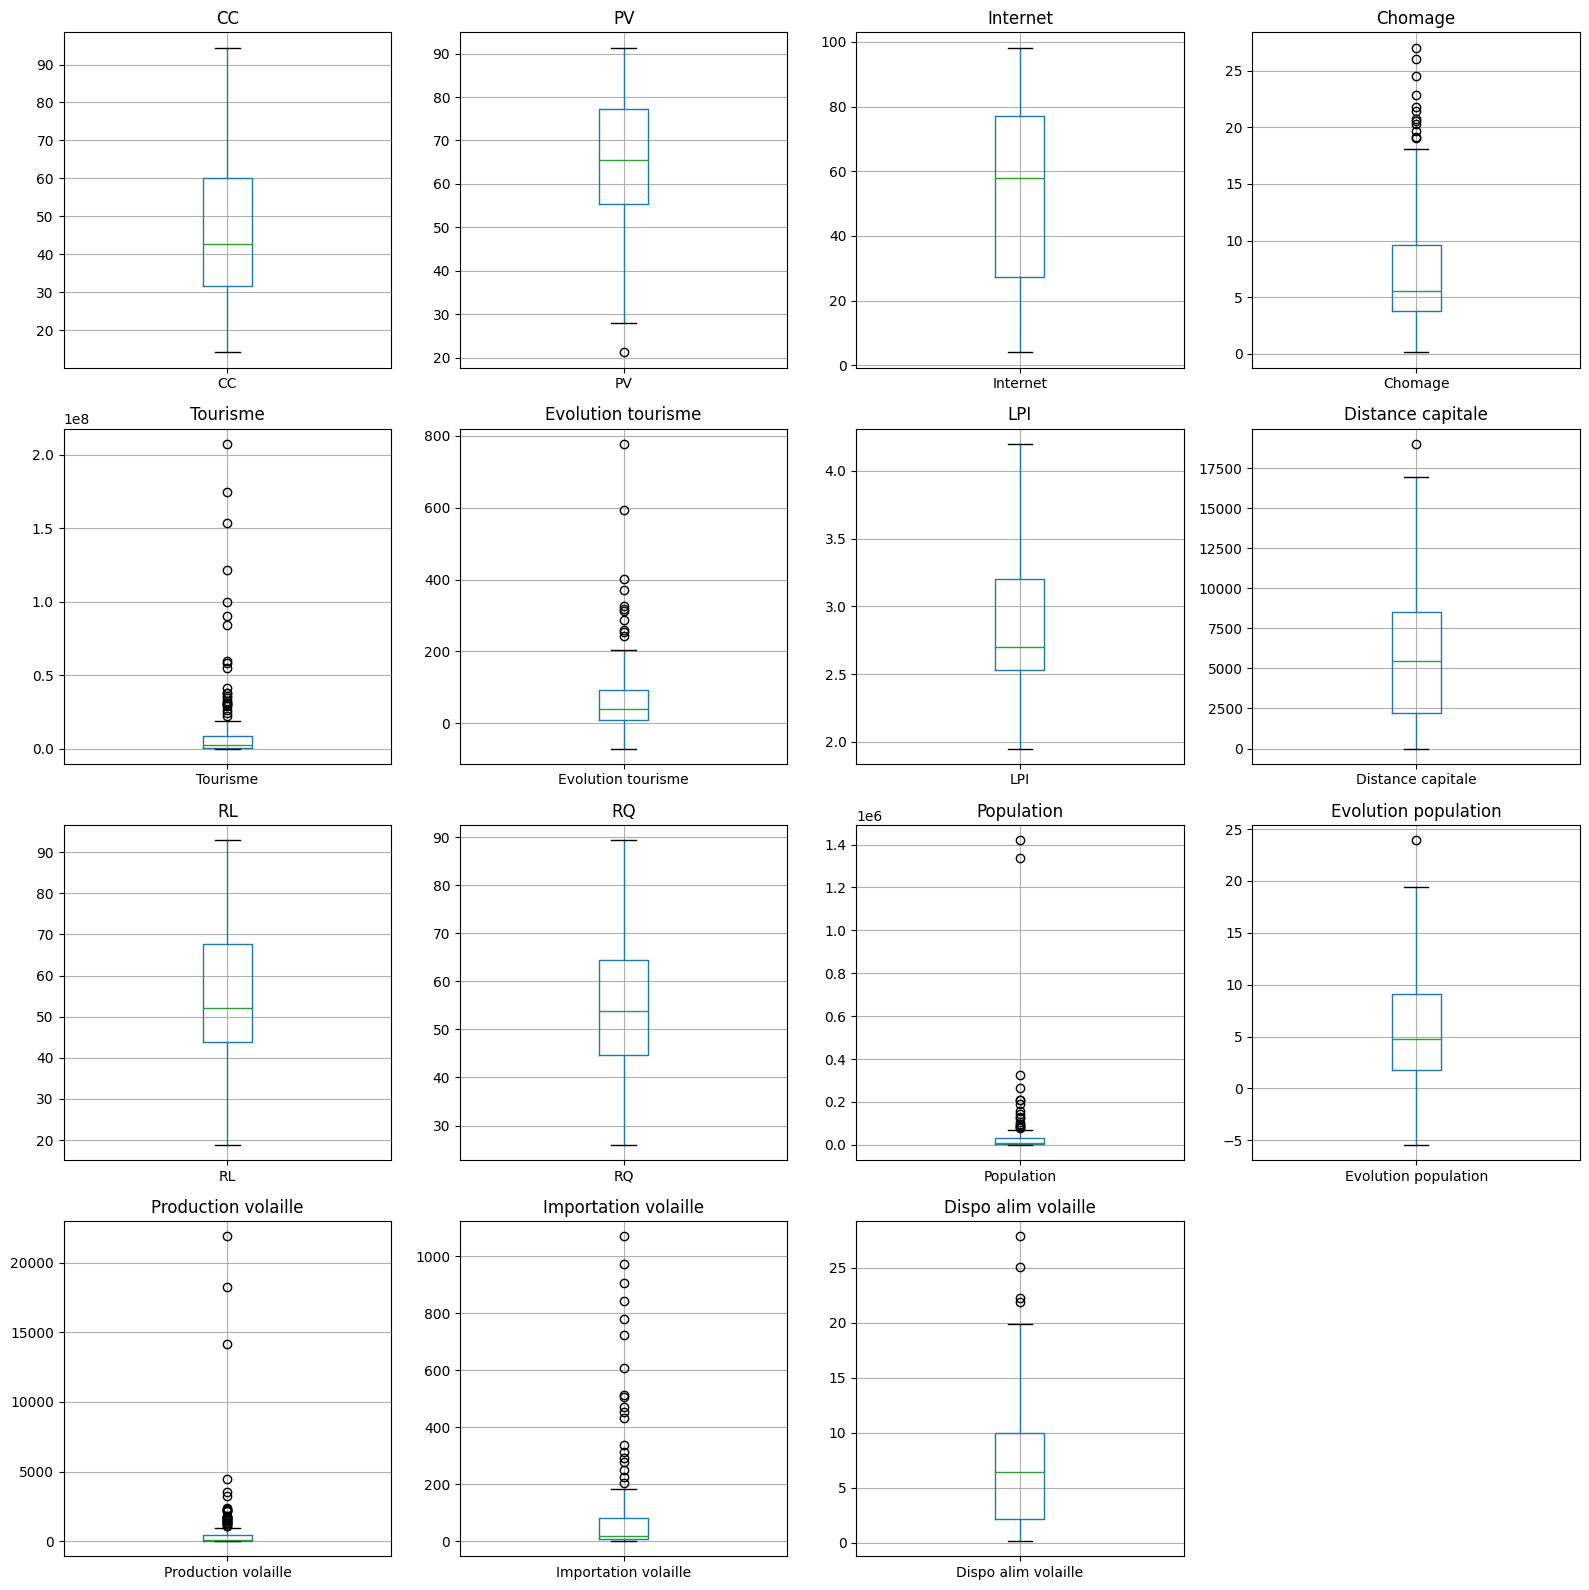

In [32]:
# Distribution of each variable
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(pestel):
    df_volaille.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)

for j in range(len(pestel), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

The boxplots highlight two types of variables: variables with a balanced distribution, and strongly skewed variables with outliers. These outliers reflect the world's economic and demographic reality: a few giant countries concentrate a disproportionate share of some variables. Rather than removing them, we apply a log transformation. It compresses extreme gaps, brings the distribution closer to a Gaussian shape, and prevents a few countries from dominating the first PCA components, without losing information. The variables concerned are population, tourism, and poultry production and imports.

In [33]:
# Log transformation
var_log = ["Tourisme", "Population", "Production volaille", "Importation volaille"]
for col in var_log:
    df_volaille[col + "_log"] = np.log1p(df_volaille[col])

In [34]:
# New log variables
var_log_1 = [
    "Tourisme_log",
    "Population_log",
    "Production volaille_log",
    "Importation volaille_log",
]

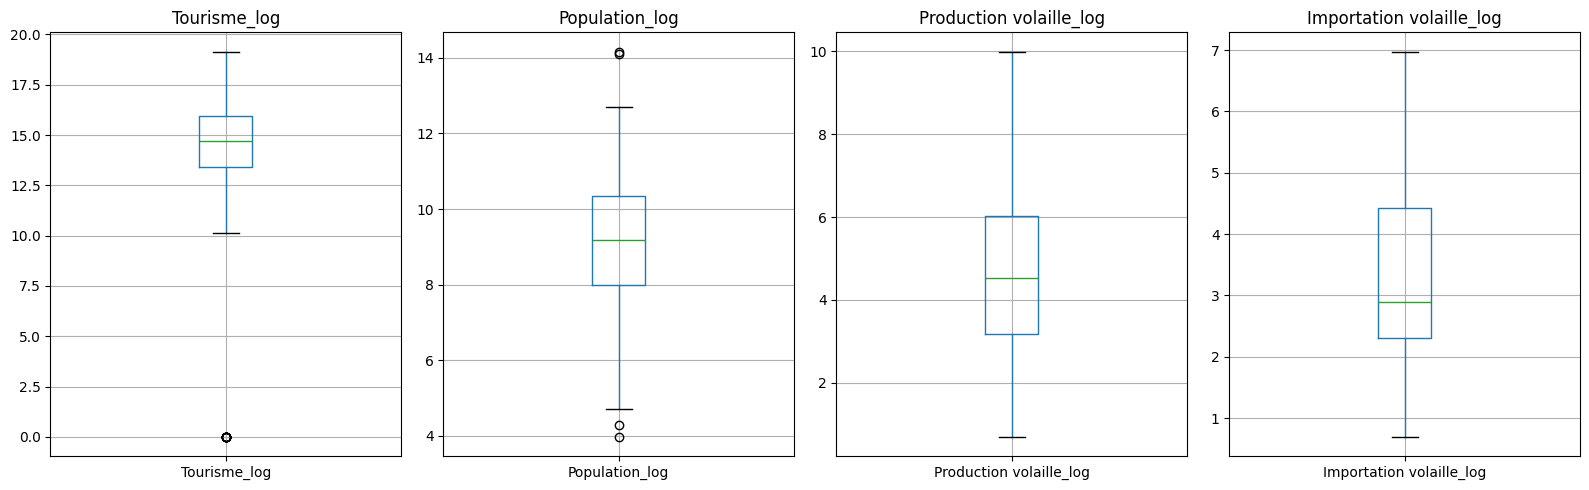

In [35]:
# Visual check of the log transformation
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, col in enumerate(var_log_1):
    df_volaille.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

The log transformation effectively flattened the distributions: the boxes are more centred and better proportioned. It reduced the disproportionate influence of outlier countries (the largest powers) and will allow the PCA to better represent the diversity of all the countries in the sample. Finally, a simulation without the log transformation showed that it lets us capture 3% more variance in the PCA.

<div style="background-color: #4ECDC4;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Step 3 - Preparing the PCA</h2>
</div>

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">3.1 - Standardisation</h3>
</div>

In [36]:
# Final list of variables for the PCA
var_acp = [col for col in pestel if col not in var_log] + var_log_1
var_acp

['CC',
 'PV',
 'Internet',
 'Chomage',
 'Evolution tourisme',
 'LPI',
 'Distance capitale',
 'RL',
 'RQ',
 'Evolution population',
 'Dispo alim volaille',
 'Tourisme_log',
 'Population_log',
 'Production volaille_log',
 'Importation volaille_log']

In [37]:
# Standardisation
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(df_volaille[var_acp])
df_scaled = pd.DataFrame(x_scaled, columns=var_acp, index=df_volaille["Name"])
df_scaled.head()

,CC,PV,Internet,Chomage,Evolution tourisme,LPI,Distance capitale,RL,RQ,Evolution population,Dispo alim volaille,Tourisme_log,Population_log,Production volaille_log,Importation volaille_log
Name,,,,,,,,,,,,,,,
Afghanistan,-1.534500,-3.040875,-1.514095,0.649721,-0.654332,-1.744051,-0.037636,-1.644200,-1.642391,1.383067,-1.178556,-3.499538,0.772158,-0.595999,0.082668
Albania,-0.528991,0.278376,0.306851,1.085410,1.812074,-0.414663,-1.114429,-0.166705,0.054372,-1.217903,-0.142447,0.364739,-0.581678,-0.950067,0.249696
Algeria,-0.502556,-1.028091,-0.240882,0.795906,-0.291427,-0.807862,-1.180496,-0.870569,-1.119768,0.600207,-0.919529,0.180567,0.842362,0.499455,-1.383214
Angola,-1.407922,-0.559329,-1.048618,1.623033,-0.760636,-1.556814,0.150444,-1.364096,-1.379671,1.804756,-0.624274,-0.379685,0.667026,-0.404484,1.500064
Argentina,-0.129430,0.368685,0.749795,0.141478,-0.249103,0.015984,1.377753,-0.131352,-0.202713,-0.268365,1.174425,0.432524,0.874301,1.500238,-0.683810


In [38]:
# Check the scaling with the mean and standard deviation
df_scaled.describe().round(2).loc[["mean", "std"]]

,CC,PV,Internet,Chomage,Evolution tourisme,LPI,Distance capitale,RL,RQ,Evolution population,Dispo alim volaille,Tourisme_log,Population_log,Production volaille_log,Importation volaille_log
mean,0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,-0.0,-0.0,0.0,-0.0,0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


All variables now have a mean of 0 and a standard deviation of 1. Standardisation was successful: all variables share the same scale, and none will outweigh another in the PCA.

<div style="background-color: #4ECDC4;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Step 4 - Correlation matrix</h2>
</div>

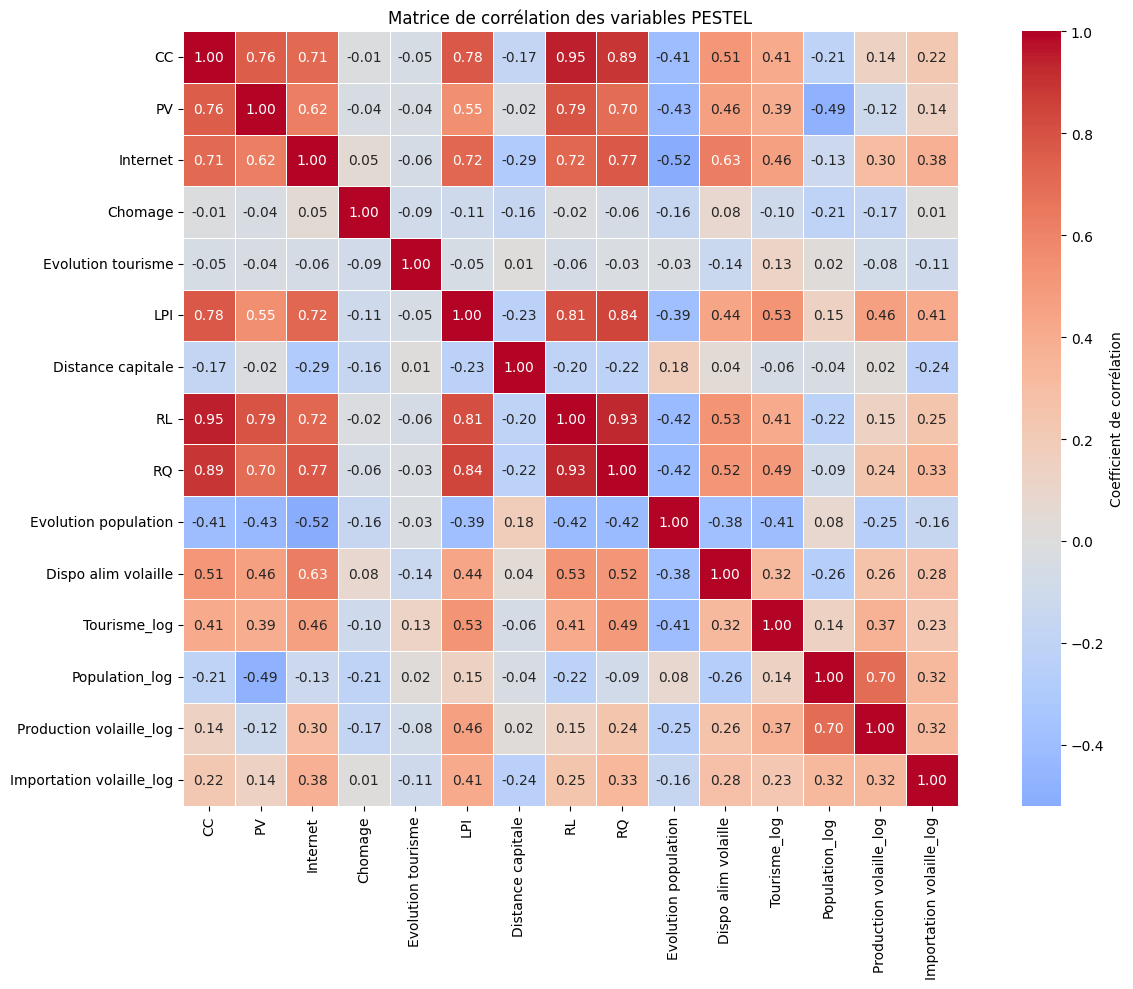

In [39]:
# Correlation heatmap of the PESTEL variables
plt.figure(figsize=(14, 10))
sns.heatmap(
    df_volaille[var_acp].corr().round(2),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Coefficient de corrélation"},
)
plt.title("Matrice de corrélation des variables PESTEL")
plt.tight_layout()
plt.show()

The correlation matrix shows strong correlations within some groups of variables. A first group brings together the governance indices (CC, PV, RL, RQ) with the LPI and internet access, which are strongly correlated with each other. A second group links population, poultry imports and poultry production. Finally, some variables such as unemployment, population growth and the distance between capitals form a third group that remains independent from the others. These correlations point to some redundancy between variables, which justifies a PCA to reduce dimensionality while keeping the essential information.

<div style="background-color: #4ECDC4;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Step 5 - Exporting the files for the PCA</h2>
</div>

In [40]:
# Export the files
df_scaled.to_csv("../data/df_scaled.csv")
df_volaille.to_csv("../data/df_volaille_final.csv")
print("Files exported successfully")

Files exported successfully


Conclusion:

Our dataset of 164 countries (covering 95.29% of the world population) has been fully cleaned, with an imputation strategy based on income level (IC) and on the specifics of each variable. A log transformation was applied to strongly skewed variables (population, tourism, poultry production and imports) to reduce the influence of giant countries on the upcoming PCA. The variables were then standardised to ensure a fair analysis. Finally, the correlation matrix reveals three main groups of variables, confirming the relevance of a PCA in the next notebook.